# OpenTRIM "270 keV He on C" example

This notebook shows how to run the "270 keV He on C" example from OpenTRIM's GUI using Python.

Basic steps:
- JSON configuration is prepared in Python and saved to a file
- `opentrim` command-line executable is called with the JSON input
- HDF5 output file is opened with `h5py`
- Data plots are created with `matplotlib`

It is assumed that `opentrim` is available on your `PATH`. If it is not, set `exe` to the full path (example in the comment below).

## 1. Load required Python modules

In [36]:
from pathlib import Path
import json
import subprocess
import tempfile
from typing import Any, Dict

import h5py
import numpy as np
import matplotlib.pyplot as plt

# 2. Generate the standard json configuration template.

Using OpenTRIM's `-t` CLI option

In [37]:
exe = "opentrim"
cmd = [exe, "-t"]

template_run = subprocess.run(
    cmd,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    timeout=20,
)

template_run.check_returncode()
Config: Dict[str, Any] = json.loads(template_run.stdout)

## 3. Edit the configuration

In [38]:
Config["Output"]["title"] = "270keV He in 100μm/cm^2 C foil"

Config["Run"]["threads"] = 0
Config["Run"]["max_no_ions"] = 1000000

Config["Simulation"]["simulation_type"] = "IonsOnly"

Config["Transport"]["flight_path_type"] = "Variable"
Config["Transport"]["min_scattering_angle"] = 0.05

Config["IonBeam"]["ion"] = {
    "symbol": "He",
    "atomic_mass": 4.0026,
    "atomic_number": 2
}
Config["IonBeam"]["energy_distribution"]["center"] = 270000.0
Config["IonBeam"]["spatial_distribution"]["center"] = [0.0, 1000.0, 1000.0]

Config["Target"]["size"] = [440.0, 2000.0, 2000.0]
Config["Target"]["cell_count"] = [1, 1, 1]
Config["Target"]["periodic_bc"] = [0, 1, 1]

Config["Target"]["materials"][0]["id"] = "Carbon foil"
Config["Target"]["materials"][0]["density"] = 2.27
Config["Target"]["materials"][0]["composition"] = [
    {"element": {"symbol": "C", "atomic_mass": 12.011}, "X": 1, "Ed": 20, "El": 3, "Es": 3, "Er": 20}
]

Config["Target"]["regions"][0]["id"] = "R1"
Config["Target"]["regions"][0]["material_id"] = "Carbon foil"
Config["Target"]["regions"][0]["size"] = [1000.0, 10000.0, 10000.0]

nx_bins = np.linspace(0.980, 1.000, 21)

Config["UserTally"] = [
    {
        "id": "AngularDistribution",
        "description": "Angular distribution of He ions exiting the foil",
        "event": "IonExit",
        "bins": {
            "nx": nx_bins.tolist(),
            "x": [440, 450],
            "atom_id": [0, 1]
        }
    }
]

## 4. Run `opentrim` in a temp folder

In [39]:
tmpdir = tempfile.TemporaryDirectory(prefix="opentrim_")
tmppath = Path(tmpdir.name)

config_path = tmppath / "config.json"
config_path.write_text(json.dumps(Config, indent=4) + "\n", encoding="utf-8")

cmd = [exe, "-f", "config.json", "-o", "result", "-s", "42"]
result = subprocess.run(
    cmd,
    cwd=tmppath,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    stdin=subprocess.DEVNULL,
    timeout=600,
)

print("returncode:", result.returncode)
if result.returncode:
    print("stderr:\n", result.stderr)

returncode: 0


## 5. Read data from HDF5 output file

In [40]:
h5_path = tmppath / "result.h5"
if not h5_path.exists():
    raise FileNotFoundError(f"Expected output file not found: {h5_path}")

with h5py.File(h5_path, "r") as f:
    data = np.asarray(f["/user_tally/AngularDistribution/data"][...])  # (1,20,1)
    nx_bins = np.asarray(f["/user_tally/AngularDistribution/bins/1"][...])  # length 21

    nx_centers = 0.5 * (nx_bins[:-1] + nx_bins[1:])
    theta = 2.0 * np.sqrt(1.0 - nx_centers)
    theta_deg = np.degrees(theta)
    delta_cos = nx_bins[1:] - nx_bins[:-1]
    S = data[0, :, 0] / delta_cos / (4.0 * np.pi)

## 6. Plot angular distribution

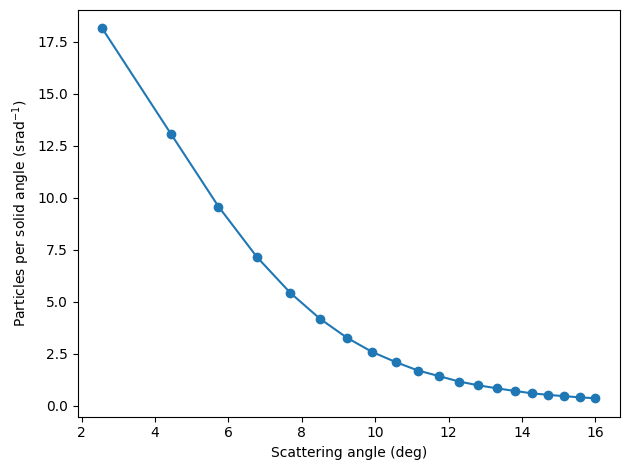

In [41]:
plt.figure()
plt.plot(theta_deg, S, marker="o")
plt.xlabel("Scattering angle (deg)")
plt.ylabel("Particles per solid angle (srad$^{-1}$)")
plt.tight_layout()
plt.show()